GOOGLE DRIVE

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

print(os.listdir('/content/drive/MyDrive/UTS CV/File'))

['Lembab', 'Basah', 'Kering']


INSTALL LIBRARY YANG DIBUTUHKAN

In [ ]:
!pip install opencv-python scikit-image scikit-learn joblib tqdm

IMPORT LIBRARY

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.ensemble import RandomForestClassifier

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import ConfusionMatrixDisplay

from skimage.filters import gabor

import matplotlib.pyplot as plt

KONFIGURASI PATH DATASET

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/UTS CV/File"

FUNGSI SEGMENTASI TANAH (MASKING BERDASARKAN HSV)

In [ ]:
def segment_soil(image):

    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    lower = np.array([0, 0, 20])
    upper = np.array([180, 255, 255])

    mask = cv2.inRange(hsv, lower, upper)

    kernel = np.ones((5,5), np.uint8)

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    segmented = cv2.bitwise_and(
        image,
        image,
        mask=mask
    )

    return segmented

FUNGSI EKSTRAKSI FITUR WARNA (RGB & HSV MEAN)

In [ ]:
def color_features(img):

    rgb_mean = np.mean(img, axis=(0,1))

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    hsv_mean = np.mean(hsv, axis=(0,1))

    features = np.concatenate(
        [rgb_mean, hsv_mean]
    )

    return features

FUNGSI EKSTRAKSI FITUR TEKSTUR (GABOR FILTER)

In [ ]:
def gabor_features(gray):

    features = []

    frequencies = [0.1, 0.3, 0.5]

    thetas = [0,
              np.pi/4,
              np.pi/2,
              3*np.pi/4]

    for theta in thetas:

        for freq in frequencies:

            real, imag = gabor(
                gray,
                frequency=freq,
                theta=theta
            )

            features.append(np.mean(real))
            features.append(np.std(real))

    return np.array(features)

LOAD DATASET & EKSTRAKSI FITUR UNTUK SETIAP GAMBAR

In [ ]:
X = []
y = []

classes = [
    "Kering",
    "Lembab",
    "Basah"
]

for label in classes:

    folder = os.path.join(
        DATASET_PATH,
        label
    )

    for file in tqdm(os.listdir(folder)):

        path = os.path.join(folder, file)

        img = cv2.imread(path)

        if img is None:
            continue

        img = cv2.resize(
            img,
            (256,256)
        )

        img = cv2.GaussianBlur(
            img,
            (5,5),
            0
        )

        img = segment_soil(img)

        color_feat = color_features(img)

        gray = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2GRAY
        )

        texture_feat = gabor_features(gray)

        features = np.concatenate(
            [color_feat, texture_feat]
        )

        X.append(features)
        y.append(label)

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

100%|██████████| 47/47 [00:31<00:00,  1.51it/s]

(138, 30)
(138,)


ENCODING LABEL KELAS (TEXT -> NUMERIK)

In [ ]:
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print(encoder.classes_)

['Basah' 'Kering' 'Lembab']


SPLIT DATA TRAIN & TEST

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

TRAINING MODEL RANDOM FOREST

In [ ]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, n_estimators=500, random_state=42)

EVALUASI MODEL (ACCURACY, CLASSIFICATION REPORT)

In [ ]:
y_pred = rf.predict(X_test)

In [ ]:
acc = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", acc)

Accuracy: 0.75


In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

       Basah       0.75      0.90      0.82        10
      Kering       0.75      0.90      0.82        10
      Lembab       0.75      0.38      0.50         8

    accuracy                           0.75        28
   macro avg       0.75      0.72      0.71        28
weighted avg       0.75      0.75      0.73        28



VISUALISASI CONFUSION MATRIX

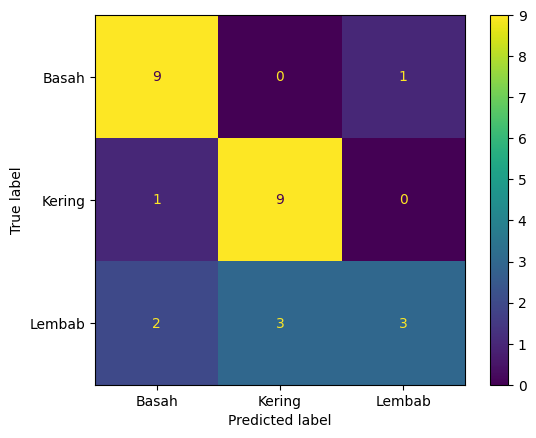

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot()

plt.show()

SIMPAN MODEL & LABEL ENCODER (JOBLIB)

In [ ]:
import joblib

joblib.dump(
    rf,
    "/content/drive/MyDrive/UTS CV/model_tanah.pkl"
)

joblib.dump(
    encoder,
    "/content/drive/MyDrive/UTS CV/label_encoder.pkl"
)

['/content/drive/MyDrive/UTS CV/label_encoder.pkl']

LOAD ULANG MODEL & LABEL ENCODER

In [ ]:
import joblib

rf = joblib.load(
    "/content/drive/MyDrive/UTS CV/model_tanah.pkl"
)

encoder = joblib.load(
    "/content/drive/MyDrive/UTS CV/label_encoder.pkl"
)

PREDIKSI GAMBAR BARU (TESTING MODEL)

In [ ]:
image_path = "/content/drive/MyDrive/UTS CV/File/Kering/4a.jpg"

img = cv2.imread(image_path)

img = cv2.resize(img,(256,256))

img = segment_soil(img)

color_feat = color_features(img)

gray = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2GRAY
)

texture_feat = gabor_features(gray)

features = np.concatenate(
    [color_feat, texture_feat]
)

features = features.reshape(1,-1)

pred = rf.predict(features)

hasil = encoder.inverse_transform(pred)

print("Kondisi Tanah =", hasil[0])

Kondisi Tanah = Kering
